In [1]:
import os
import warnings
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'
warnings.filterwarnings('ignore')

import sys
sys.path.append('/app')

from src.data.dataset import create_dataset
from src.data.preprocessing import preprocess_image_with_filter
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np

print("✓ Módulos cargados")

2026-02-10 18:28:47.521751: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-02-10 18:28:47.521819: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-02-10 18:28:47.522886: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


✓ Módulos cargados


In [2]:
# Cargar datos
TRAIN_PATH = Path('/app/data/raw/Training_Set/Training_Set')
train_df = pd.read_csv(TRAIN_PATH / 'RFMiD_Training_Labels.csv')

# Tomar subset pequeño para prueba
train_sample = train_df.sample(20, random_state=42)

print(f"✓ {len(train_sample)} imágenes para prueba")

✓ 20 imágenes para prueba


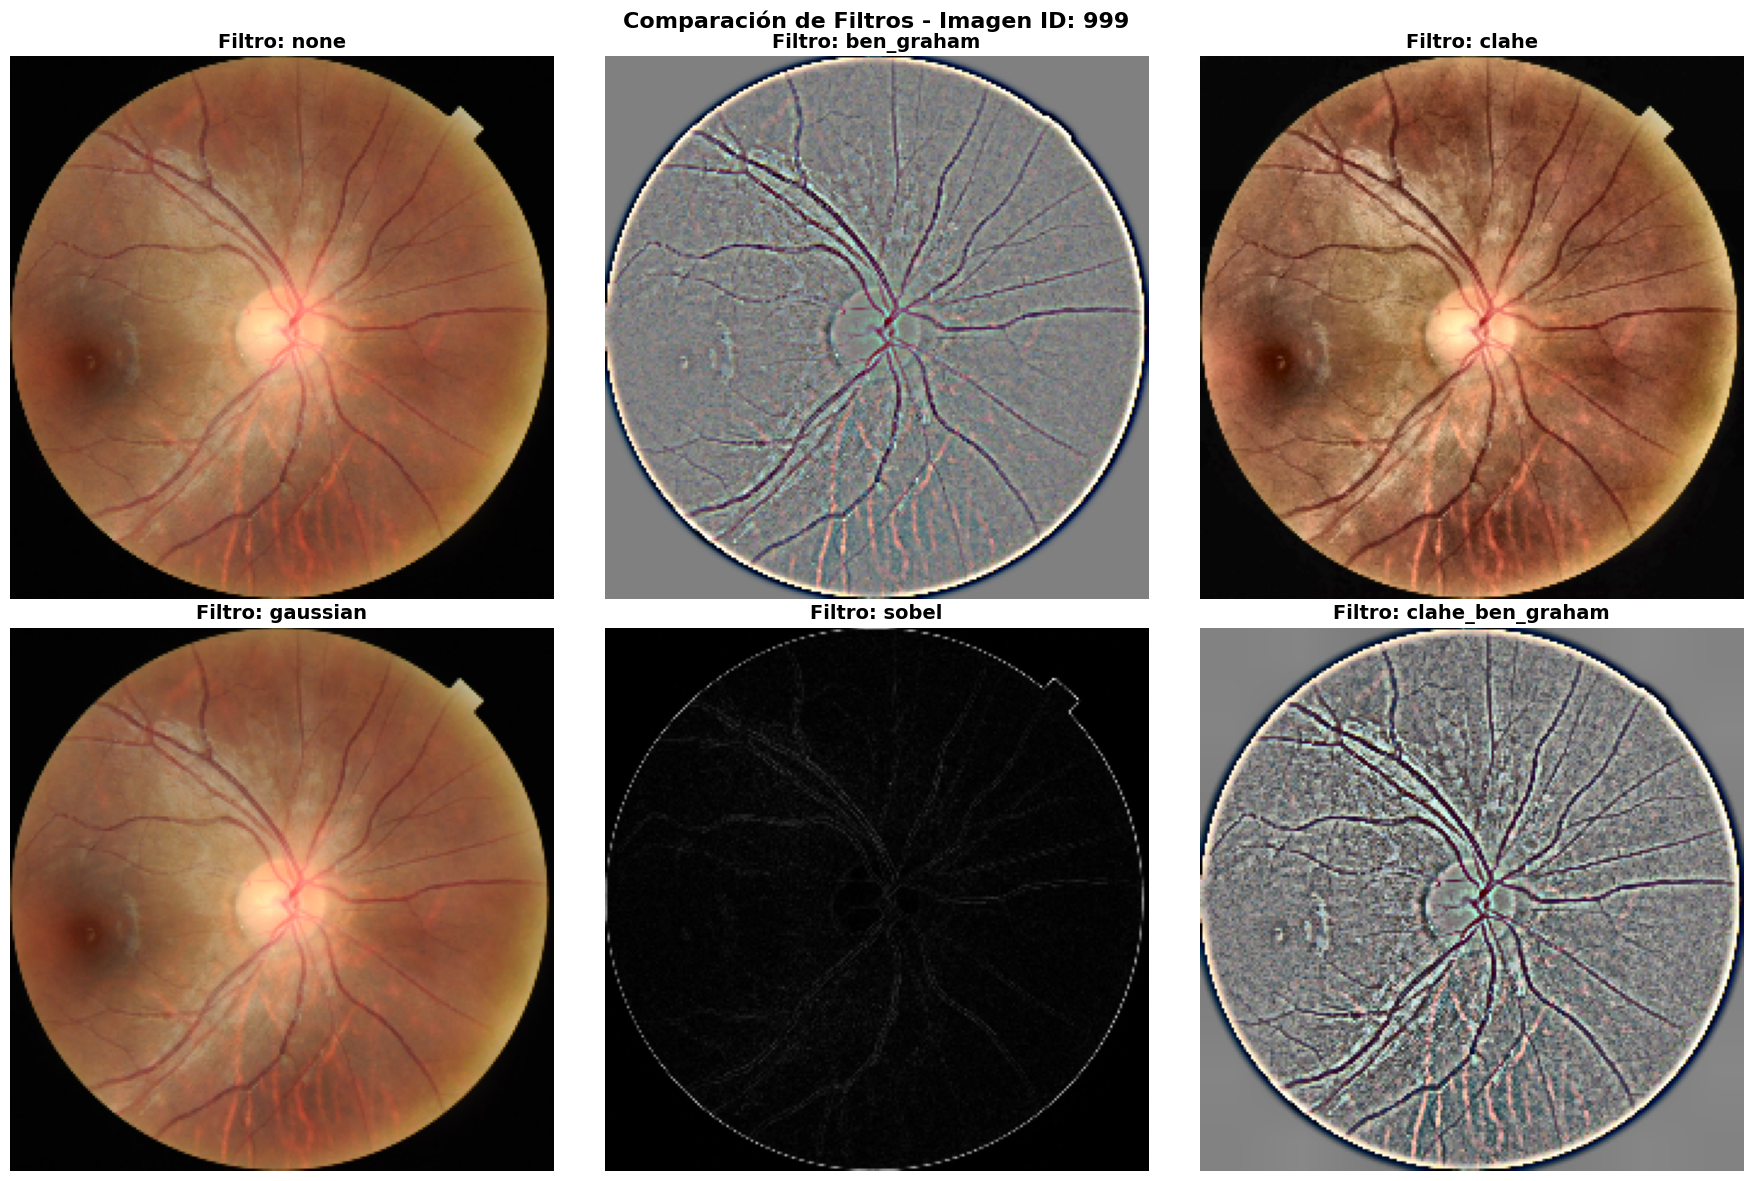

In [3]:
# Tomar una imagen de muestra
sample_img_id = train_sample.iloc[0]['ID']
img_path = TRAIN_PATH / 'Training' / f"{sample_img_id}.png"

# Lista de filtros a probar
filters = ['none', 'ben_graham', 'clahe', 'gaussian', 'sobel', 'clahe_ben_graham']

# Procesar con cada filtro
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

for idx, filter_name in enumerate(filters):
    try:
        img = preprocess_image_with_filter(str(img_path), filter_name=filter_name)
        axes[idx].imshow(img)
        axes[idx].set_title(f"Filtro: {filter_name}", fontsize=14, fontweight='bold')
        axes[idx].axis('off')
    except Exception as e:
        axes[idx].text(0.5, 0.5, f"Error: {str(e)}", 
                      ha='center', va='center', transform=axes[idx].transAxes)
        axes[idx].set_title(f"Filtro: {filter_name} (ERROR)", fontsize=14)
        axes[idx].axis('off')

plt.suptitle(f"Comparación de Filtros - Imagen ID: {sample_img_id}", fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()